# HGNet 이 새 마스킹(hyi fixedmask)에 robust 함을 시각화

pretrain_v4 의 ORFormer+HGNet 은 **검은마스킹(solid)으로만** occlusion 학습했는데, hyi split 의 masked 는 **8가지 appearance**(blur/checker/noise/stripe/solid...). HGNet 이 본 적 없는 마스킹에서 landmark 를 잘 복원하는지 검증.

- ① appearance별 NME (clean 기준선 대비)
- ② 가린 눈 위 landmark overlay (HGNet 복원 vs clean 정답)

**결론(미리)**: 새 마스킹(noise/blur)은 clean 수준 복원, 오히려 검은마스킹(solid)이 정보 완전소실로 최악 → HGNet 은 마스킹 종류에 robust.

In [1]:
import sys, re, importlib.util as ilu
import numpy as np, torch, cv2, glob
from pathlib import Path
import matplotlib.pyplot as plt

R = Path("/home/yg/fusion/pretrain_v4")
for p in ["configs","src/data","src"]: sys.path.insert(0,str(R/p))
sys.path.insert(0,"/data/shared/orformer/vendor")
from default import get_cfg
from heatmap_gen import denorm_points
from models.VQVAE import VQVAE
from models.simple_vit import ORFormer
from models.StackedHGNet import IntergrationStackedHGNet
import torchvision.transforms as T, models.quantizer as _q

DEV = "cuda" if torch.cuda.is_available() else "cpu"; _q.device=torch.device(DEV)
NORM = T.Compose([T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
cfg=get_cfg(); cfg.DMD.GT_SOURCE="mediapipe"; ds=cfg.DMD
s=ilu.spec_from_file_location("fr7","/data/shared/scuppy/Gaze_image_model/src/data/face_regions7.py")
fr7=ilu.module_from_spec(s); s.loader.exec_module(fr7)
EYE=np.array(sorted(set(fr7.FACE_REGIONS_7["left_eye"])|set(fr7.FACE_REGIONS_7["right_eye"])|set(range(468,478))))
ALL=np.arange(478)
print("device:",DEV)

device: cuda


## 모델 로드 + 함수

In [2]:
# ORFormer + HGNet (pretrain_v4) 로드
vit=ORFormer(image_size=16,patch_size=1,num_classes=2048,dim=256,depth=3,heads=8,mlp_dim=512,channels=256)
orf=VQVAE(h_dim=128,res_h_dim=32,output_dim=ds.NUM_EDGE,n_res_layers=2,n_embeddings=2048,
          embedding_dim=256,code_dim=256,beta=0.25,vit=vit).to(DEV).eval()
orf.load_state_dict(torch.load(str(R/"artifacts/phase2_orformer_fixed/best.pt"),map_location=DEV,weights_only=False).get("model_state_dict"),strict=False)
hg=IntergrationStackedHGNet(classes_num=[ds.NUM_POINT,ds.NUM_EDGE,ds.NUM_POINT],
                            edge_info=[list(x) for x in ds.EDGE_INFO],nstack=4).to(DEV).eval()
hg.load_state_dict(torch.load(str(R/"artifacts/phase3a_hgnet_478/best.pt"),map_location=DEV,weights_only=False)["hgnet_state_dict"],strict=True)

@torch.no_grad()
def hgnet_lm(crop112):
    rgb=np.stack([cv2.resize(crop112,(256,256))]*3,-1); res=cv2.resize(rgb,(64,64))
    _,ref,*_=orf(NORM(res).unsqueeze(0).to(DEV)); _,lm=hg(NORM(rgb).unsqueeze(0).to(DEV),reference_heatmaps=ref)
    return denorm_points(lm,64,64)[0].cpu().numpy()*(112/64)

def square_crop_gt(frame,bb,gt_full,pad=0.1,sz=112):
    x1,y1,x2,y2=bb; cx,cy=(x1+x2)/2,(y1+y2)/2; ss=max(x2-x1,y2-y1)*(1+2*pad); ax,ay=cx-ss/2,cy-ss/2
    h,w=frame.shape[:2]; a,b=max(0,int(ax)),max(0,int(ay)); a2,b2=min(w,int(cx+ss/2)),min(h,int(cy+ss/2))
    c=frame[b:b2,a:a2]
    if c.size==0: return None,None
    if c.ndim==3: c=cv2.cvtColor(c,cv2.COLOR_BGR2GRAY)
    return cv2.resize(c,(sz,sz)), (gt_full-np.array([ax,ay]))*(sz/ss)

def nme(p,g,idx):
    al,ar=ds.NME_ANCHOR; d=max(np.linalg.norm(g[al]-g[ar]),1e-6)
    return np.linalg.norm(p[idx]-g[idx],axis=1).mean()/d*100
print("HGNet+ORFormer loaded")

HGNet+ORFormer loaded


In [3]:
VID="/data/shared/Occlusion_subset_dataset/region_occlusion_video_dataset_v3_original_fixedmask/videos"
BB="/data/shared/Occlusion_subset_dataset/region_occlusion_video_dataset_v3_original_fixedmask_yolo_face_facemesh/yolo_face"
FM="/data/shared/DMD_landmarks/facemesh"
# 학습도메인(solid) vs 새 마스킹(OOD) 순으로
APPS=["solid","soft_solid","stripe","checker","soft_noise","smooth_noise","blur_patch","noise"]

def one_sample(app, want_region="both_eyes"):
    """app 의 영상 1개에서 (crop, hgnet_pred, clean_gt) 1 frame 반환"""
    vids=glob.glob(f"{VID}/{want_region}/{app}/*.mp4") or glob.glob(f"{VID}/*/{app}/*.mp4")
    for vid in vids:
        name=Path(vid).stem; region=Path(vid).parent.parent.name
        m=re.search(r'(g[A-Z]_\d+_s\d+_[0-9T;:+-]+)_ir_face',name)
        if not m: continue
        bbf=f"{BB}/{region}/{app}/{name}_face5pt.npz"
        cf=glob.glob(f"{FM}/**/{m.group(1)}_ir_face_facemesh.npz",recursive=True)
        if not Path(bbf).exists() or not cf: continue
        zb=np.load(bbf,allow_pickle=True); bbox=zb["bbox"]; det=zb["detected"].astype(bool)
        zc=np.load(cf[0],allow_pickle=True); clean_lm=zc["landmarks"]; cdet=zc["detected"].astype(bool)
        valid=np.where(det&cdet[:len(det)])[0]
        if len(valid)==0: continue
        fi=int(valid[len(valid)//2])
        cap=cv2.VideoCapture(vid); cap.set(cv2.CAP_PROP_POS_FRAMES,fi); ok,fr=cap.read(); cap.release()
        if not ok: continue
        crop,gt=square_crop_gt(fr,bbox[fi],clean_lm[fi][:,:2])
        if crop is None or not np.isfinite(gt).all(): continue
        return crop, hgnet_lm(crop), gt, region
    return None
print("ready")

ready


## ① appearance별 NME 막대그래프

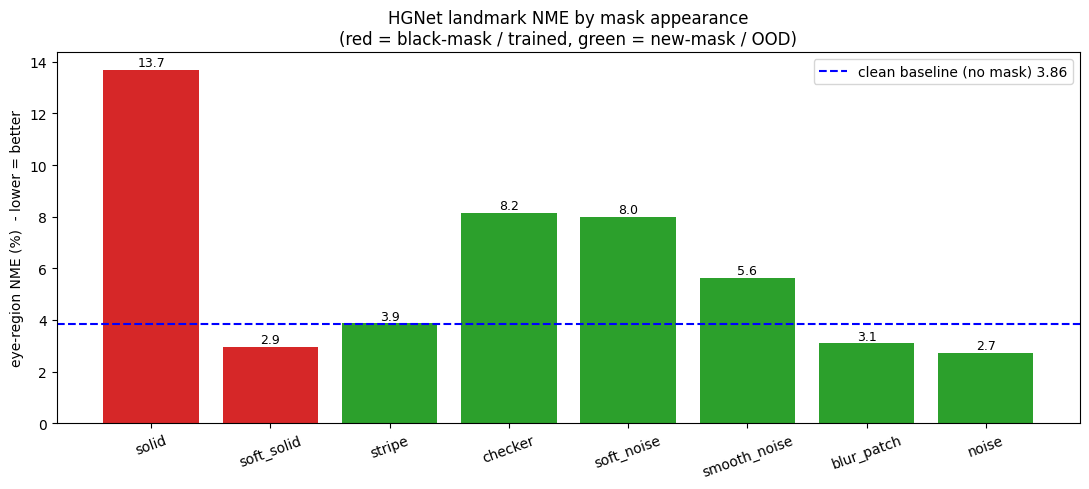

-> new masks (green) near clean baseline; black-mask solid (red) is worst


In [4]:
# ① appearance별 NME (clean baseline 대비) — 막대그래프
# clean baseline 은 검증에서 eye 3.86 / all 4.14
CLEAN_EYE, CLEAN_ALL = 3.86, 4.14
res={}
for app in APPS:
    en,an=[],[]
    for vid in (glob.glob(f"{VID}/*/{app}/*.mp4")[:3]):
        name=Path(vid).stem; region=Path(vid).parent.parent.name
        m=re.search(r'(g[A-Z]_\d+_s\d+_[0-9T;:+-]+)_ir_face',name)
        if not m: continue
        bbf=f"{BB}/{region}/{app}/{name}_face5pt.npz"; cf=glob.glob(f"{FM}/**/{m.group(1)}_ir_face_facemesh.npz",recursive=True)
        if not Path(bbf).exists() or not cf: continue
        zb=np.load(bbf,allow_pickle=True); bbox=zb["bbox"]; det=zb["detected"].astype(bool)
        zc=np.load(cf[0],allow_pickle=True); clean_lm=zc["landmarks"]; cdet=zc["detected"].astype(bool)
        valid=np.where(det&cdet[:len(det)])[0]
        if len(valid)==0: continue
        cap=cv2.VideoCapture(vid)
        for fi in valid[np.linspace(0,len(valid)-1,4,dtype=int)]:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(fi)); ok,fr=cap.read()
            if not ok: continue
            crop,gt=square_crop_gt(fr,bbox[fi],clean_lm[fi][:,:2])
            if crop is None or not np.isfinite(gt).all(): continue
            pred=hgnet_lm(crop); en.append(nme(pred,gt,EYE)); an.append(nme(pred,gt,ALL))
        cap.release()
    if en: res[app]=(np.mean(en),np.mean(an))

fig,ax=plt.subplots(figsize=(11,5))
names=list(res); eye=[res[a][0] for a in names]
colors=["#d62728" if a in("solid","soft_solid") else "#2ca02c" for a in names]
ax.bar(names,eye,color=colors)
ax.axhline(CLEAN_EYE,color="blue",ls="--",label=f"clean baseline (no mask) {CLEAN_EYE}")
ax.set_ylabel("eye-region NME (%)  - lower = better")
ax.set_title("HGNet landmark NME by mask appearance\n(red = black-mask / trained, green = new-mask / OOD)")
ax.legend(); ax.tick_params(axis="x",rotation=20)
for i,v in enumerate(eye): ax.text(i,v+0.15,f"{v:.1f}",ha="center",fontsize=9)
plt.tight_layout(); plt.savefig("/data/shared/scuppy/yg/occ_cnn_v1/fig_hgnet_nme_bar.png",dpi=120); plt.show()
print("-> new masks (green) near clean baseline; black-mask solid (red) is worst")

## ② 가린 눈 위 landmark overlay (HGNet 주황 vs clean GT 파랑)

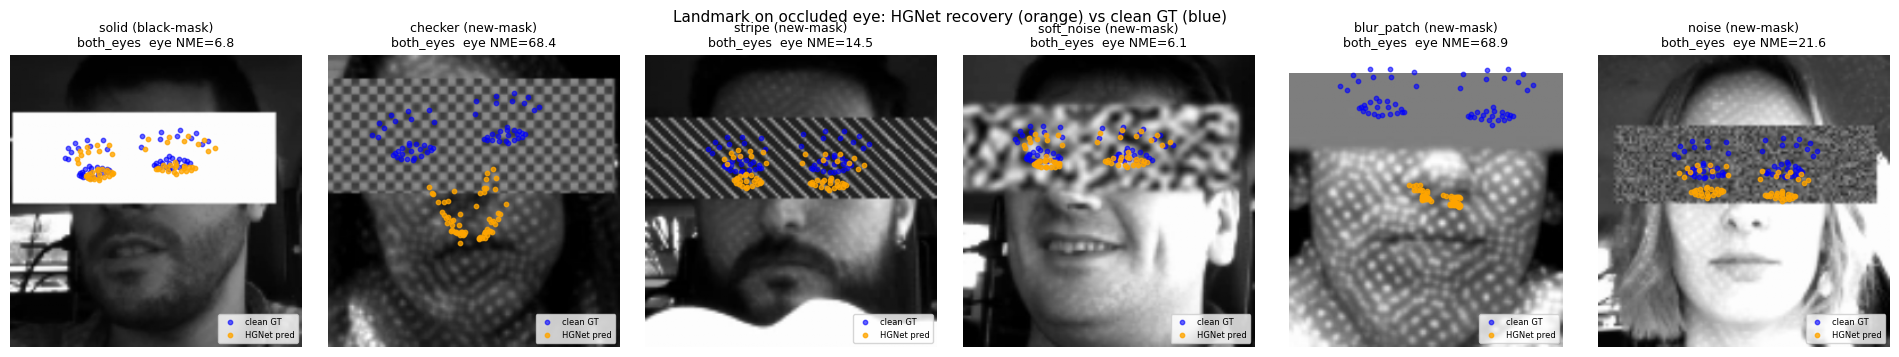

-> noise/blur: orange(HGNet) overlaps blue(GT) well; solid(black): slight drift from info loss


In [5]:
# ② 가린 얼굴 위 landmark overlay — HGNet pred(주황) vs clean GT(파랑)
# 검은마스킹(solid) vs 새 마스킹(noise/blur) 시각 대비
show_apps=["solid","checker","stripe","soft_noise","blur_patch","noise"]
fig,axes=plt.subplots(1,len(show_apps),figsize=(3.2*len(show_apps),3.6))
for ax,app in zip(axes,show_apps):
    r=one_sample(app)
    if r is None: ax.set_title(f"{app}\n(no data)"); ax.axis("off"); continue
    crop,pred,gt,region=r
    ax.imshow(cv2.resize(crop,(256,256)),cmap="gray"); sc=256/112
    ax.scatter(gt[EYE,0]*sc,gt[EYE,1]*sc,s=10,c="blue",alpha=0.6,label="clean GT")
    ax.scatter(pred[EYE,0]*sc,pred[EYE,1]*sc,s=10,c="orange",alpha=0.8,label="HGNet pred")
    e=nme(pred,gt,EYE)
    tag="black-mask" if app in("solid","soft_solid") else "new-mask"
    ax.set_title(f"{app} ({tag})\n{region}  eye NME={e:.1f}",fontsize=9)
    ax.legend(loc="lower right",fontsize=6); ax.axis("off")
plt.suptitle("Landmark on occluded eye: HGNet recovery (orange) vs clean GT (blue)",fontsize=11)
plt.tight_layout(); plt.savefig("/data/shared/scuppy/yg/occ_cnn_v1/fig_hgnet_overlay.png",dpi=120); plt.show()
print("-> noise/blur: orange(HGNet) overlaps blue(GT) well; solid(black): slight drift from info loss")

## ③ mask_region × appearance — 많은 예시 (부위별 NME)
각 cell: 가린 얼굴 + HGNet pred(주황) vs clean GT(파랑). 빨간 제목 = iris NME>8(무너짐).

In [6]:
# mask_region(가린 위치) × appearance(마스크 종류) 별 샘플 수집 helper
from collections import defaultdict
IRIS=np.arange(468,478); LEYE=np.array(fr7.FACE_REGIONS_7['left_eye']); REYE=np.array(fr7.FACE_REGIONS_7['right_eye'])
NOSE=np.array(fr7.FACE_REGIONS_7['nose']); MOUTH=np.array(fr7.FACE_REGIONS_7['mouth'])
LM_REGIONS=[('iris',IRIS),('L_eye',LEYE),('R_eye',REYE),('nose',NOSE),('mouth',MOUTH),('ALL',ALL)]
MASK_REGIONS=["left_eye","right_eye","both_eyes","mouth"]
ALL_APPS=["solid","soft_solid","stripe","checker","noise","soft_noise","smooth_noise","blur_patch"]
def region_nmes(pred,gt):
    al,ar=ds.NME_ANCHOR; d=max(np.linalg.norm(gt[al]-gt[ar]),1e-6)
    return {r:float(np.linalg.norm(pred[idx]-gt[idx],axis=1).mean()/d*100) for r,idx in LM_REGIONS}
def collect(mask_region, app, max_vid=1, frames=1):
    out=[]
    for vid in glob.glob(f"{VID}/{mask_region}/{app}/*.mp4")[:max_vid]:
        name=Path(vid).stem; m=re.search(r'(g[A-Z]_\d+_s\d+_[0-9T;:+-]+)_ir_face',name)
        if not m: continue
        bbf=f"{BB}/{mask_region}/{app}/{name}_face5pt.npz"; cf=glob.glob(f"{FM}/**/{m.group(1)}_ir_face_facemesh.npz",recursive=True)
        if not Path(bbf).exists() or not cf: continue
        zb=np.load(bbf,allow_pickle=True); bbox=zb["bbox"]; det=zb["detected"].astype(bool)
        zc=np.load(cf[0],allow_pickle=True); clean_lm=zc["landmarks"]; cdet=zc["detected"].astype(bool)
        valid=np.where(det&cdet[:len(det)])[0]
        if len(valid)==0: continue
        cap=cv2.VideoCapture(vid)
        for fi in valid[np.linspace(0,len(valid)-1,frames,dtype=int)]:
            cap.set(cv2.CAP_PROP_POS_FRAMES,int(fi)); ok,fr=cap.read()
            if not ok: continue
            crop,gt=square_crop_gt(fr,bbox[fi],clean_lm[fi][:,:2])
            if crop is None or not np.isfinite(gt).all(): continue
            out.append((crop,hgnet_lm(crop),gt))
        cap.release()
    return [(c,p,g,region_nmes(p,g)) for c,p,g in out]
print("helper ready:",MASK_REGIONS,"| apps:",len(ALL_APPS))

helper ready: ['left_eye', 'right_eye', 'both_eyes', 'mouth'] | apps: 8


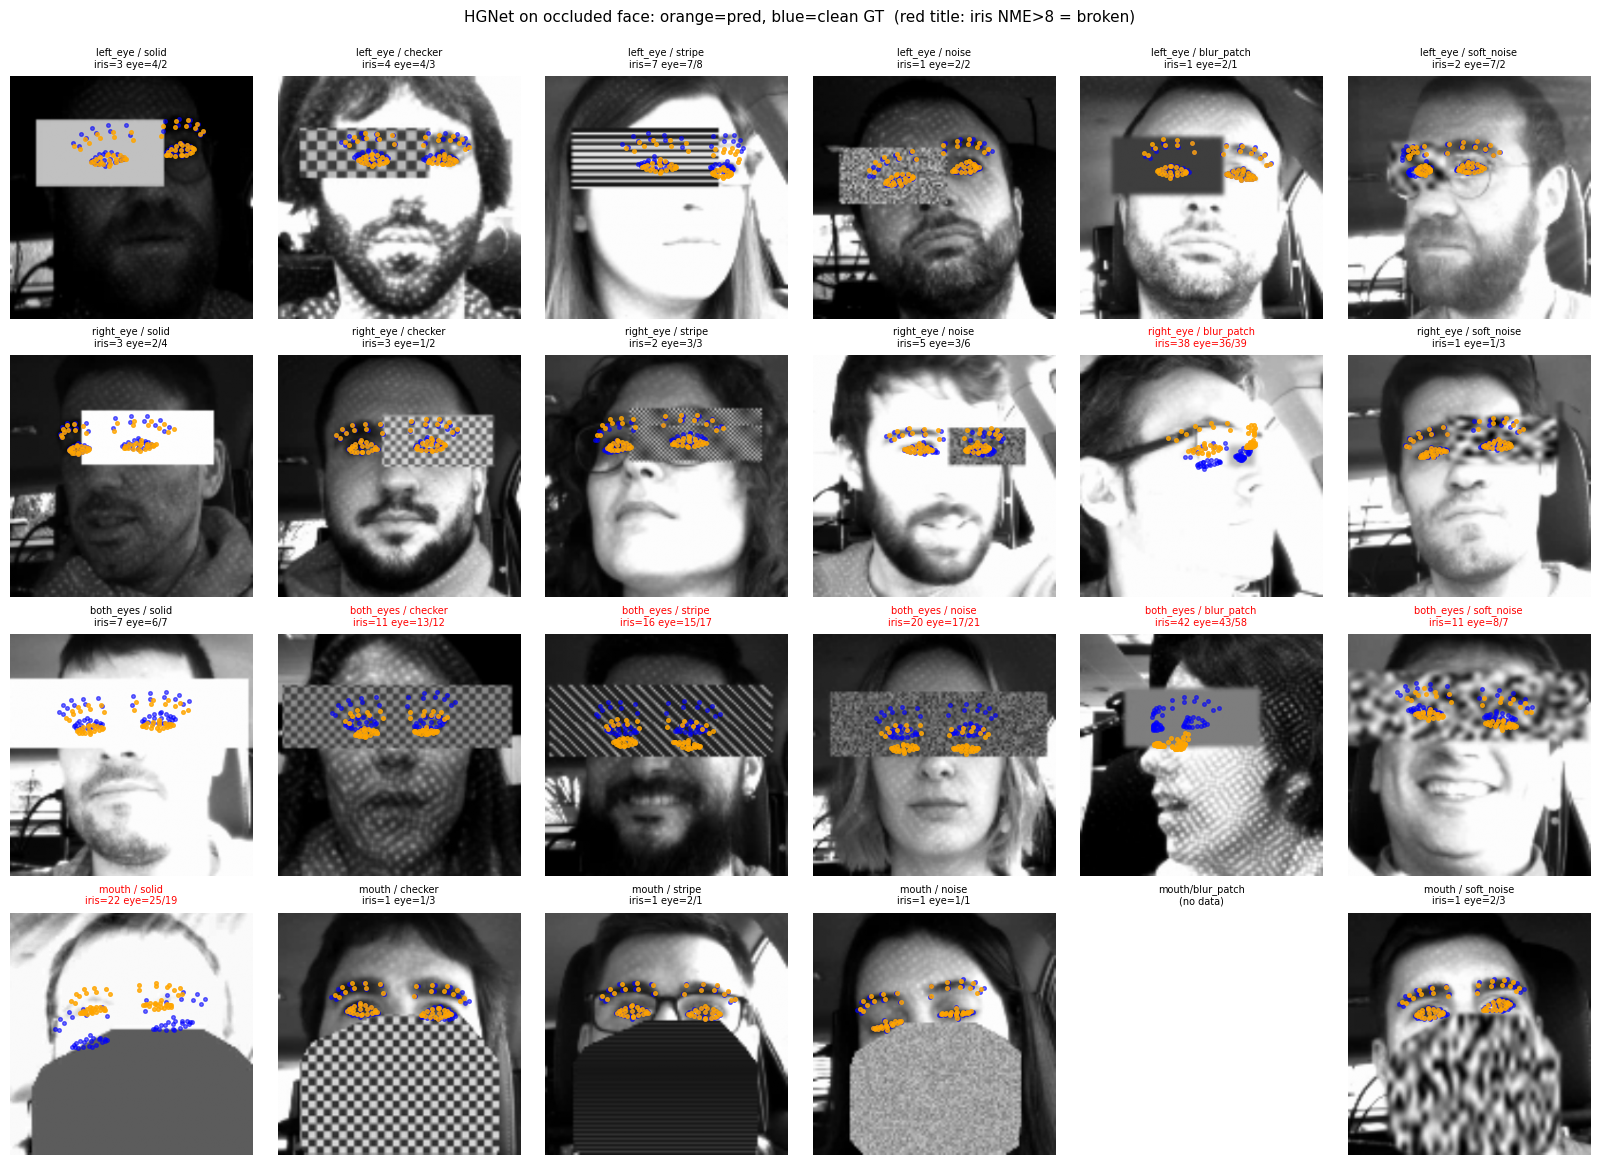

-> both_eyes 행에서 iris 빨강(>8)=양눈가림시 무너짐. left/right_eye·mouth 양호.


In [7]:
# mask_region(행) × appearance(열) overlay grid — 많은 예시 + 부위별 NME
SHOW_APPS=["solid","checker","stripe","noise","blur_patch","soft_noise"]
fig,axes=plt.subplots(len(MASK_REGIONS),len(SHOW_APPS),figsize=(2.7*len(SHOW_APPS),2.9*len(MASK_REGIONS)))
for ri,mr in enumerate(MASK_REGIONS):
    for ci,app in enumerate(SHOW_APPS):
        ax=axes[ri,ci]; samp=collect(mr,app)
        if not samp: ax.axis("off"); ax.set_title(f"{mr}/{app}\n(no data)",fontsize=7); continue
        crop,pred,gt,rn=samp[0]; sc=256/112
        ax.imshow(cv2.resize(crop,(256,256)),cmap="gray")
        ax.scatter(gt[EYE,0]*sc,gt[EYE,1]*sc,s=7,c="blue",alpha=0.55)
        ax.scatter(pred[EYE,0]*sc,pred[EYE,1]*sc,s=7,c="orange",alpha=0.8)
        ax.set_title(f"{mr} / {app}\niris={rn['iris']:.0f} eye={rn['L_eye']:.0f}/{rn['R_eye']:.0f}",
                     fontsize=7,color=("red" if rn['iris']>8 else "black")); ax.axis("off")
plt.suptitle("HGNet on occluded face: orange=pred, blue=clean GT  (red title: iris NME>8 = broken)",fontsize=11,y=1.0)
plt.tight_layout(); plt.savefig("/data/shared/scuppy/yg/occ_cnn_v1/fig_grid_maskregion_app.png",dpi=110,bbox_inches="tight"); plt.show()
print("-> both_eyes 행에서 iris 빨강(>8)=양눈가림시 무너짐. left/right_eye·mouth 양호.")

## ④ 부위별 NME 히트맵 (어디 가림 × 어느 부위)

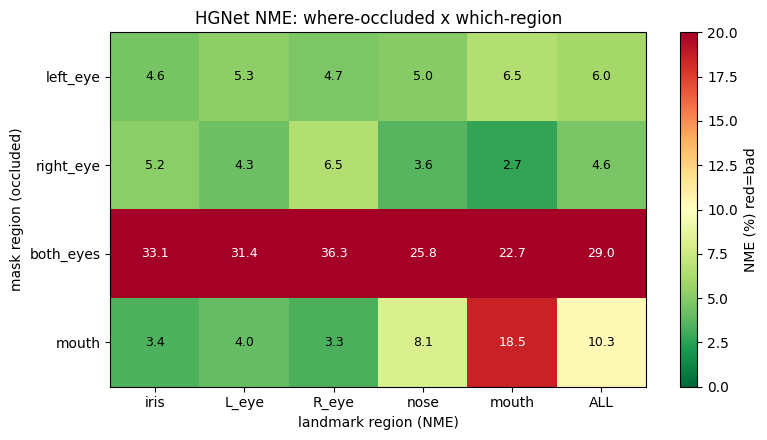

-> both_eyes 행 iris/eye 빨강(높은 NME), 나머지 가림은 눈 NME 낮음(초록).


In [8]:
# 부위별 NME 히트맵: mask_region(가린곳) × landmark_region(부위)
mat=np.full((len(MASK_REGIONS),len(LM_REGIONS)),np.nan)
for ri,mr in enumerate(MASK_REGIONS):
    accum=defaultdict(list)
    for app in ALL_APPS:
        for crop,pred,gt,rn in collect(mr,app,max_vid=1,frames=2):
            for r in rn: accum[r].append(rn[r])
    for ci,(rname,_) in enumerate(LM_REGIONS):
        if accum[rname]: mat[ri,ci]=np.mean(accum[rname])
fig,ax=plt.subplots(figsize=(8,4.5))
im=ax.imshow(mat,cmap="RdYlGn_r",vmin=0,vmax=20,aspect="auto")
ax.set_xticks(range(len(LM_REGIONS))); ax.set_xticklabels([r for r,_ in LM_REGIONS])
ax.set_yticks(range(len(MASK_REGIONS))); ax.set_yticklabels(MASK_REGIONS)
ax.set_xlabel("landmark region (NME)"); ax.set_ylabel("mask region (occluded)")
for i in range(len(MASK_REGIONS)):
    for j in range(len(LM_REGIONS)):
        if not np.isnan(mat[i,j]): ax.text(j,i,f"{mat[i,j]:.1f}",ha="center",va="center",fontsize=9,color="white" if mat[i,j]>12 else "black")
fig.colorbar(im,label="NME (%) red=bad"); ax.set_title("HGNet NME: where-occluded x which-region")
plt.tight_layout(); plt.savefig("/data/shared/scuppy/yg/occ_cnn_v1/fig_region_nme_heatmap.png",dpi=120); plt.show()
print("-> both_eyes 행 iris/eye 빨강(높은 NME), 나머지 가림은 눈 NME 낮음(초록).")